In [1]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer , WordNetLemmatizer
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.model_selection import train_test_split
import pickle
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"spamCollection.csv" , sep='\\t', names=['label','message'],encoding='utf-8')

In [3]:
df = df.replace({'"': ''}, regex=True)

In [4]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,"Ok lar... Joking wif u oni...,,,,,,,,,,,,,"
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.shape

(5574, 2)

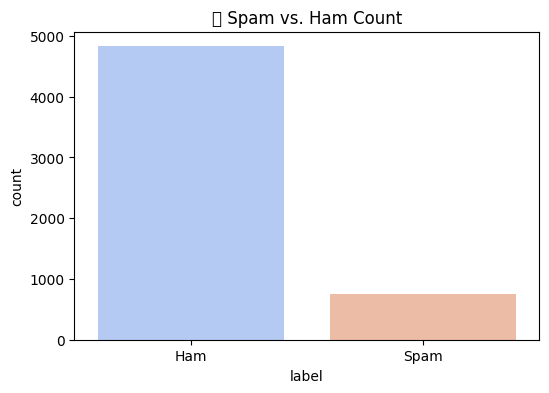

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
df1 = df.copy()  
df1['label'] = df1['label'].map({'ham': 0, 'spam': 1})
plt.figure(figsize=(6,4))
sns.countplot(x=df1['label'], palette='coolwarm')
plt.title("📊 Spam vs. Ham Count")
plt.xticks(ticks=[0,1], labels=["Ham", "Spam"])
plt.show()

In [7]:
lamitizer = WordNetLemmatizer()

In [8]:
train = []
for i in range(len(df)):
    review = re.sub('^[a-zA-Z]' , ' ' , df['message'][i])
    review = review.lower()
    review = review.split()
    review = [lamitizer.lemmatize(word) for word in review if not word in stopwords.words('english')]
    review = ' '.join(review)
    train.append(review)

In [9]:
print(train[0])

jurong point, crazy.. available bugis n great world la e buffet... cine got amore wat...,,,,,,,,,,,,


In [10]:
cv = CountVectorizer(max_features=5000)
x = cv.fit_transform(train).toarray()

In [11]:
y = pd.get_dummies(df['label'])
y.head()

,ham,spam
0,True,False
1,True,False
2,False,True
3,True,False
4,True,False


In [12]:
y = y.iloc[:,1].values
print(y)

[False False  True ... False False False]


In [13]:
train_x,test_x,train_y,test_y = train_test_split(x,y,test_size = 0.20,random_state = 42)

In [14]:
from sklearn.naive_bayes import MultinomialNB

In [15]:
mb = MultinomialNB()
mb.fit(train_x,train_y)

MultinomialNB()

In [16]:
pred = mb.predict(test_x)
print(pred)

[False False False ... False False  True]


In [17]:
cm = confusion_matrix(pred,test_y)
print(cm)

[[943   6]
 [ 11 155]]


In [18]:
acc = accuracy_score(pred,test_y)
acc

0.9847533632286996

In [19]:
pickle.dump(cv,open('transform.pkl','wb'))

In [20]:
pickle.dump(mb,open('nlp model.pkl','wb'))

# RandomForestClassifier

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(train_x, train_y)

pred_rf = rf.predict(test_x)
print(pred_rf)

cm_rf = confusion_matrix(pred_rf, test_y)
print(cm_rf)

acc_rf = accuracy_score(pred_rf, test_y)
print("Random Forest Accuracy:", acc_rf)


[False False False ... False False  True]
[[954  22]
 [  0 139]]
Random Forest Accuracy: 0.9802690582959641


#  SVM  MODEL

In [22]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', probability=True, random_state=42)
svm.fit(train_x, train_y)
pred_svm = svm.predict(test_x)
print(pred_svm)
cm_svm = confusion_matrix(pred_svm, test_y)
print(cm_svm)

acc_svm = accuracy_score(pred_svm, test_y)
print("SVM Accuracy:", acc_svm)


[False False False ... False False  True]
[[952  19]
 [  2 142]]
SVM Accuracy: 0.9811659192825112
